In [ ]:

# Install required packages
!pip install -q ultralytics xgboost joblib opencv-python matplotlib pandas numpy

# Imports
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("Cell 1 completed successfully.")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)

Cell 1 completed successfully.
NumPy version: 2.0.2
Pandas version: 2.3.3
OpenCV version: 4.13.0


In [3]:
# ============================================================
# CELL 2 — MODEL AND IMAGE PATHS
# ============================================================

# Replace these paths with the actual paths in your environment.

CLASSIFICATION_MODEL_PATH = "/kaggle/input/models/manojrajan01/yolo-class/pytorch/classification/1/best.pt"

SEGMENTATION_MODEL_PATH = "/kaggle/input/models/manojrajan01/yolo-segmentation/pytorch/segmentation/1/weights/best.pt"

SHELF_LIFE_MODEL_PATH = "/kaggle/input/models/manojrajan01/food-shelf-life-prediction/scikitlearn/defaultxgboost-shelf-life-predictor/1/shelf_life_xgboost_model.pkl"

SHELF_LIFE_FEATURE_COLUMNS_PATH = "/kaggle/input/models/manojrajan01/food-shelf-life-prediction/scikitlearn/defaultxgboost-shelf-life-predictor/1/model_feature_columns.pkl"

INPUT_IMAGE_PATH = "/kaggle/input/datasets/manojrajan01/my-test-image2/carrot0.jpg"


# Check that the important files exist
print("Checking model and input paths...\n")

print("Classification model:")
print(CLASSIFICATION_MODEL_PATH)
print("Exists:", os.path.exists(CLASSIFICATION_MODEL_PATH))

print("\nSegmentation model:")
print(SEGMENTATION_MODEL_PATH)
print("Exists:", os.path.exists(SEGMENTATION_MODEL_PATH))

print("\nShelf-life XGBoost model:")
print(SHELF_LIFE_MODEL_PATH)
print("Exists:", os.path.exists(SHELF_LIFE_MODEL_PATH))

print("\nFeature columns:")
print(SHELF_LIFE_FEATURE_COLUMNS_PATH)
print("Exists:", os.path.exists(SHELF_LIFE_FEATURE_COLUMNS_PATH))

print("\nInput image:")
print(INPUT_IMAGE_PATH)
print("Exists:", os.path.exists(INPUT_IMAGE_PATH))

Checking model and input paths...

Classification model:
/kaggle/input/models/manojrajan01/yolo-class/pytorch/classification/1/best.pt
Exists: True

Segmentation model:
/kaggle/input/models/manojrajan01/yolo-segmentation/pytorch/segmentation/1/weights/best.pt
Exists: True

Shelf-life XGBoost model:
/kaggle/input/models/manojrajan01/food-shelf-life-prediction/scikitlearn/defaultxgboost-shelf-life-predictor/1/shelf_life_xgboost_model.pkl
Exists: True

Feature columns:
/kaggle/input/models/manojrajan01/food-shelf-life-prediction/scikitlearn/defaultxgboost-shelf-life-predictor/1/model_feature_columns.pkl
Exists: True

Input image:
/kaggle/input/datasets/manojrajan01/my-test-image2/carrot0.jpg
Exists: True


In [4]:
# ============================================================
# CELL 3 — LOAD ALL MODELS
# ============================================================

# Load YOLO classification model
classification_model = YOLO(CLASSIFICATION_MODEL_PATH)

# Load YOLO segmentation model
segmentation_model = YOLO(SEGMENTATION_MODEL_PATH)

# Load XGBoost shelf-life model
shelf_life_model = joblib.load(SHELF_LIFE_MODEL_PATH)

# Load the exact feature columns used during XGBoost training
shelf_life_feature_columns = joblib.load(
    SHELF_LIFE_FEATURE_COLUMNS_PATH
)


# ------------------------------------------------------------
# Display loaded model information
# ------------------------------------------------------------

print("Classification model loaded successfully.")
print("Classification classes:")
print(classification_model.names)

print("\nSegmentation model loaded successfully.")
print("Segmentation classes:")
print(segmentation_model.names)

print("\nShelf-life XGBoost model loaded successfully.")
print("Shelf-life model type:")
print(type(shelf_life_model))

print("\nShelf-life feature columns loaded successfully.")
print("Number of feature columns:", len(shelf_life_feature_columns))
print("\nFeature columns:")
print(shelf_life_feature_columns)

Classification model loaded successfully.
Classification classes:
{0: 'Apple_Fresh', 1: 'Apple_Rotten', 2: 'Banana_Fresh', 3: 'Banana_Rotten', 4: 'Bellpepper_Fresh', 5: 'Bellpepper_Rotten', 6: 'Bitter_Gourd_Fresh', 7: 'Bitter_Gourd_Rotten', 8: 'Carrot_Fresh', 9: 'Carrot_Rotten', 10: 'Cucumber_Fresh', 11: 'Cucumber_Rotten', 12: 'Grape_Fresh', 13: 'Grape_Rotten', 14: 'Guava_Fresh', 15: 'Guava_Rotten', 16: 'Jujube_Fresh', 17: 'Jujube_Rotten', 18: 'Mango_Fresh', 19: 'Mango_Rotten', 20: 'Orange_Fresh', 21: 'Orange_Rotten', 22: 'Pomegranate_Fresh', 23: 'Pomegranate_Rotten', 24: 'Potato_Fresh', 25: 'Potato_Rotten', 26: 'Strawberry_Fresh', 27: 'Strawberry_Rotten', 28: 'Tomato_Fresh', 29: 'Tomato_Rotten', 30: 'Watermelon_Fresh', 31: 'Watermelon_Rotten'}

Segmentation model loaded successfully.
Segmentation classes:
{0: 'Fruit', 1: 'Mold', 2: 'Rotten', 3: 'Vegetable'}

Shelf-life XGBoost model loaded successfully.
Shelf-life model type:
<class 'xgboost.sklearn.XGBRegressor'>

Shelf-life feature 

Input image loaded successfully.
Image shape: (468, 427, 3)

Classification Result
---------------------
Class ID   : 9
Class Name : Carrot_Rotten
Confidence : 0.9997


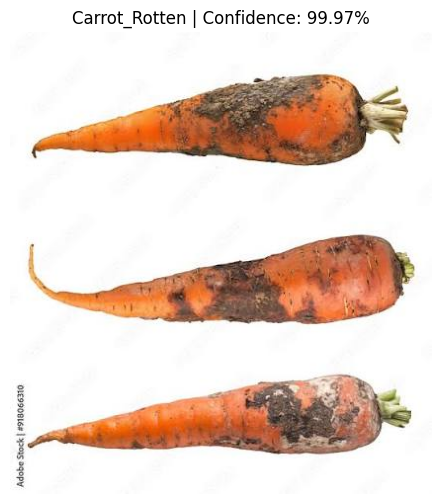

In [5]:
# ============================================================
# CELL 4 — TEST CLASSIFICATION MODEL
# ============================================================

# Classification settings
CLASSIFICATION_CONF_THRESHOLD = 0.25
CLASSIFICATION_IMG_SIZE = 224

# Read input image
image = cv2.imread(INPUT_IMAGE_PATH)

if image is None:
    raise FileNotFoundError(
        f"Could not read input image: {INPUT_IMAGE_PATH}"
    )

print("Input image loaded successfully.")
print("Image shape:", image.shape)

# Run YOLO classification
classification_results = classification_model.predict(
    source=image,
    imgsz=CLASSIFICATION_IMG_SIZE,
    verbose=False
)

# Get first result
classification_result = classification_results[0]

# Get top-1 prediction
top1_class_id = int(classification_result.probs.top1)
top1_confidence = float(classification_result.probs.top1conf)
top1_class_name = classification_model.names[top1_class_id]

print("\nClassification Result")
print("---------------------")
print("Class ID   :", top1_class_id)
print("Class Name :", top1_class_name)
print("Confidence :", f"{top1_confidence:.4f}")

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title(
    f"{top1_class_name} | Confidence: {top1_confidence:.2%}"
)
plt.axis("off")
plt.show()

Segmentation inference completed.
Number of detected objects: 9
Object 1: Vegetable | Confidence: 0.8957
Object 2: Vegetable | Confidence: 0.8759
Object 3: Vegetable | Confidence: 0.8745
Object 4: Rotten | Confidence: 0.8177
Object 5: Rotten | Confidence: 0.5001
Object 6: Rotten | Confidence: 0.4038
Object 7: Mold | Confidence: 0.3930
Object 8: Mold | Confidence: 0.2761
Object 9: Rotten | Confidence: 0.2617


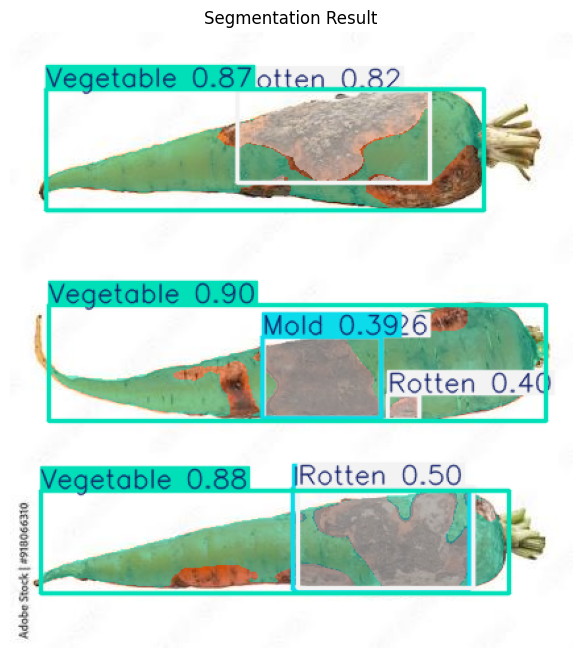

In [6]:
# ============================================================
# CELL 5 — TEST SEGMENTATION MODEL
# ============================================================

# Segmentation settings
SEGMENTATION_CONF_THRESHOLD = 0.25
SEGMENTATION_IOU_THRESHOLD = 0.45
SEGMENTATION_IMG_SIZE = 640

# Segmentation class names
SEGMENTATION_CLASSES = {
    0: "Fruit",
    1: "Mold",
    2: "Rotten",
    3: "Vegetable"
}

# Run segmentation
segmentation_results = segmentation_model.predict(
    source=image,
    conf=SEGMENTATION_CONF_THRESHOLD,
    iou=SEGMENTATION_IOU_THRESHOLD,
    imgsz=SEGMENTATION_IMG_SIZE,
    verbose=False
)

segmentation_result = segmentation_results[0]

print("Segmentation inference completed.")

# Check detections
if segmentation_result.boxes is None or len(segmentation_result.boxes) == 0:
    print("No objects detected by the segmentation model.")

else:
    print("Number of detected objects:", len(segmentation_result.boxes))

    for i in range(len(segmentation_result.boxes)):

        class_id = int(
            segmentation_result.boxes.cls[i].item()
        )

        confidence = float(
            segmentation_result.boxes.conf[i].item()
        )

        class_name = SEGMENTATION_CLASSES.get(
            class_id,
            segmentation_model.names.get(
                class_id,
                str(class_id)
            )
        )

        print(
            f"Object {i + 1}: "
            f"{class_name} | "
            f"Confidence: {confidence:.4f}"
        )

# Display segmentation result
segmented_image = segmentation_result.plot()

plt.figure(figsize=(10, 8))
plt.imshow(
    cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB)
)
plt.title("Segmentation Result")
plt.axis("off")
plt.show()

In [7]:
# ============================================================
# CELL 6 — CALCULATE AREA FOR EACH FOOD INSTANCE
# ============================================================

FOOD_CLASSES = {"Fruit", "Vegetable"}
SPOILAGE_CLASSES = {"Rotten", "Mold"}

food_objects = []

boxes = segmentation_result.boxes
masks = segmentation_result.masks

if boxes is None or len(boxes) == 0:
    print("No objects detected.")

elif masks is None:
    print("No segmentation masks available.")

else:

    # --------------------------------------------------------
    # Process every detected object
    # --------------------------------------------------------

    for i in range(len(boxes)):

        class_id = int(
            boxes.cls[i].item()
        )

        class_name = SEGMENTATION_CLASSES.get(
            class_id,
            segmentation_model.names.get(
                class_id,
                str(class_id)
            )
        )

        confidence = float(
            boxes.conf[i].item()
        )

        # Get this object's mask
        mask = masks.data[i].cpu().numpy()

        mask = cv2.resize(
            mask,
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        mask_bool = mask > 0.5

        area_pixels = int(mask_bool.sum())

        # ----------------------------------------------------
        # Store only actual food objects
        # ----------------------------------------------------

        if class_name in FOOD_CLASSES:

            food_objects.append({
                "object_id": len(food_objects) + 1,
                "class_id": class_id,
                "class_name": class_name,
                "confidence": confidence,
                "mask": mask_bool,
                "food_area_pixels": area_pixels,
                "rotten_area_pixels": 0,
                "mold_area_pixels": 0
            })


    # --------------------------------------------------------
    # Find rotten/mold pixels INSIDE each food mask
    # --------------------------------------------------------

    for food in food_objects:

        food_mask = food["mask"]

        food_rotten_area = 0
        food_mold_area = 0

        for j in range(len(boxes)):

            spoilage_class_id = int(
                boxes.cls[j].item()
            )

            spoilage_class_name = SEGMENTATION_CLASSES.get(
                spoilage_class_id,
                segmentation_model.names.get(
                    spoilage_class_id,
                    str(spoilage_class_id)
                )
            )

            if spoilage_class_name not in SPOILAGE_CLASSES:
                continue

            # Get spoilage mask
            spoilage_mask = masks.data[j].cpu().numpy()

            spoilage_mask = cv2.resize(
                spoilage_mask,
                (image.shape[1], image.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

            spoilage_mask = spoilage_mask > 0.5

            # ------------------------------------------------
            # IMPORTANT:
            # Count spoilage only where it overlaps this food
            # ------------------------------------------------

            overlap = food_mask & spoilage_mask

            overlap_area = int(overlap.sum())

            if spoilage_class_name == "Rotten":
                food_rotten_area += overlap_area

            elif spoilage_class_name == "Mold":
                food_mold_area += overlap_area

        food["rotten_area_pixels"] = food_rotten_area
        food["mold_area_pixels"] = food_mold_area


# ============================================================
# PRINT PER-FOOD RESULTS
# ============================================================

print("\nPer-Food Segmentation Analysis")
print("================================")

print("Food objects detected:", len(food_objects))

for food in food_objects:

    food_area = food["food_area_pixels"]
    rotten_area = food["rotten_area_pixels"]
    mold_area = food["mold_area_pixels"]

    if food_area > 0:

        rotten_percentage = (
            rotten_area / food_area
        ) * 100

        mold_percentage = (
            mold_area / food_area
        ) * 100

    else:

        rotten_percentage = 0.0
        mold_percentage = 0.0

    food["rotten_percentage"] = min(
        100.0,
        rotten_percentage
    )

    food["mold_percentage"] = min(
        100.0,
        mold_percentage
    )

    print(f"\nFood Object {food['object_id']}")
    print("------------------------")
    print("Class              :", food["class_name"])
    print("Confidence         :", f"{food['confidence']:.4f}")
    print("Food area          :", food_area, "pixels")
    print("Rotten area        :", rotten_area, "pixels")
    print("Mold area          :", mold_area, "pixels")
    print(
        "Rotten percentage  :",
        f"{food['rotten_percentage']:.2f}%"
    )
    print(
        "Mold percentage    :",
        f"{food['mold_percentage']:.2f}%"
    )


Per-Food Segmentation Analysis
Food objects detected: 3

Food Object 1
------------------------
Class              : Vegetable
Confidence         : 0.8957
Food area          : 12326 pixels
Rotten area        : 218 pixels
Mold area          : 131 pixels
Rotten percentage  : 1.77%
Mold percentage    : 1.06%

Food Object 2
------------------------
Class              : Vegetable
Confidence         : 0.8759
Food area          : 9645 pixels
Rotten area        : 622 pixels
Mold area          : 799 pixels
Rotten percentage  : 6.45%
Mold percentage    : 8.28%

Food Object 3
------------------------
Class              : Vegetable
Confidence         : 0.8745
Food area          : 9842 pixels
Rotten area        : 43 pixels
Mold area          : 0 pixels
Rotten percentage  : 0.44%
Mold percentage    : 0.00%


In [8]:
# ============================================================
# CELL 7 — CALCULATE FRESHNESS FOR EACH FOOD OBJECT
# ============================================================

ROTTEN_WEIGHT = 1.0
MOLD_WEIGHT = 1.2

for food in food_objects:

    rotten_percentage = food["rotten_percentage"]
    mold_percentage = food["mold_percentage"]

    # Calculate spoilage penalty for this food object only
    spoilage_score = (
        rotten_percentage * ROTTEN_WEIGHT
        + mold_percentage * MOLD_WEIGHT
    )

    # Calculate freshness
    freshness_percentage = 100.0 - spoilage_score

    # Keep result between 0 and 100
    freshness_percentage = max(
        0.0,
        min(100.0, freshness_percentage)
    )

    # Store freshness inside the food object
    food["freshness_percentage"] = freshness_percentage


# ============================================================
# PRINT FRESHNESS FOR EACH FOOD OBJECT
# ============================================================

print("\nPer-Food Freshness Analysis")
print("============================")

for food in food_objects:

    print(f"\nFood Object {food['object_id']}")
    print("------------------------")
    print("Class              :", food["class_name"])
    print(
        "Rotten percentage  :",
        f"{food['rotten_percentage']:.2f}%"
    )
    print(
        "Mold percentage    :",
        f"{food['mold_percentage']:.2f}%"
    )
    print(
        "Freshness          :",
        f"{food['freshness_percentage']:.2f}%"
    )


Per-Food Freshness Analysis

Food Object 1
------------------------
Class              : Vegetable
Rotten percentage  : 1.77%
Mold percentage    : 1.06%
Freshness          : 96.96%

Food Object 2
------------------------
Class              : Vegetable
Rotten percentage  : 6.45%
Mold percentage    : 8.28%
Freshness          : 83.61%

Food Object 3
------------------------
Class              : Vegetable
Rotten percentage  : 0.44%
Mold percentage    : 0.00%
Freshness          : 99.56%


In [9]:
# ============================================================
# CELL 8 — BUILD XGBOOST FEATURES
# ============================================================

# Default storage conditions
temperature_c = 25.0
humidity_percent = 60.0
storage_duration_days = 0.0

storage_area = "Room Temperature"
packaging_material = "Loose"

# ------------------------------------------------------------
# Function to create the exact feature row expected by XGBoost
# ------------------------------------------------------------

def create_shelf_life_features(food):
    
    # Start with all expected features set to 0
    features = {
        column: 0
        for column in shelf_life_feature_columns
    }

    # --------------------------------------------------------
    # Numerical features
    # --------------------------------------------------------
    
    if "temperature_c" in features:
        features["temperature_c"] = temperature_c

    if "humidity_percent" in features:
        features["humidity_percent"] = humidity_percent

    if "freshness_percentage" in features:
        features["freshness_percentage"] = (
            food["freshness_percentage"]
        )

    if "storage_duration_days" in features:
        features["storage_duration_days"] = (
            storage_duration_days
        )

    # --------------------------------------------------------
    # Food category
    # --------------------------------------------------------
    
    food_class = food["class_name"]

    # The segmentation model gives Fruit / Vegetable.
    # The classification model gives the actual food name.
    food_category = top1_class_name

    food_category_column = (
        f"food_category_{food_category}"
    )

    if food_category_column in features:
        features[food_category_column] = 1

    # --------------------------------------------------------
    # Food type
    # --------------------------------------------------------
    
    if "food_type_Vegetable" in features:
        
        if food_class == "Vegetable":
            features["food_type_Vegetable"] = 1

    # --------------------------------------------------------
    # Storage area
    # --------------------------------------------------------
    
    storage_area_column = (
        f"storage_area_{storage_area}"
    )

    if storage_area_column in features:
        features[storage_area_column] = 1

    # --------------------------------------------------------
    # Packaging material
    # --------------------------------------------------------
    
    packaging_column = (
        f"packaging_material_{packaging_material}"
    )

    if packaging_column in features:
        features[packaging_column] = 1

    # --------------------------------------------------------
    # Create DataFrame in EXACT training-column order
    # --------------------------------------------------------
    
    feature_df = pd.DataFrame(
        [[features[column] for column in shelf_life_feature_columns]],
        columns=shelf_life_feature_columns
    )

    return feature_df


# ============================================================
# CREATE FEATURES FOR EVERY FOOD OBJECT
# ============================================================

for food in food_objects:

    food["shelf_life_features"] = create_shelf_life_features(
        food
    )


# ============================================================
# DISPLAY FEATURES
# ============================================================

print("XGBoost feature creation completed.")
print()

for food in food_objects:

    print(
        f"Food Object {food['object_id']} "
        f"({top1_class_name})"
    )

    print(
        food["shelf_life_features"].to_string(index=False)
    )

    print("-" * 70)

XGBoost feature creation completed.

Food Object 1 (Carrot_Rotten)
 temperature_c  humidity_percent  freshness_percentage  storage_duration_days  food_category_Banana  food_category_Beetroot  food_category_Bell Pepper  food_category_Cabbage  food_category_Carrot  food_category_Cauliflower  food_category_Chilli Pepper  food_category_Corn  food_category_Cucumber  food_category_Eggplant  food_category_Ginger  food_category_Grapes  food_category_Guava  food_category_Kiwi  food_category_Lemon  food_category_Mango  food_category_Onion  food_category_Orange  food_category_Papaya  food_category_Potato  food_category_Tomato  food_type_Vegetable  storage_area_Dark Dry Storage  storage_area_Pantry  storage_area_Refrigerator  storage_area_Room Temperature  packaging_material_Loose  packaging_material_Mesh/Net Bag  packaging_material_Paper Bag  packaging_material_Perforated Plastic Bag  packaging_material_Plastic Bag  packaging_material_Plastic Container  packaging_material_Plastic Wrap  packaging_

In [10]:
# ============================================================
# CELL 9 — TEST XGBOOST SHELF-LIFE MODEL
# ============================================================

print("Testing XGBoost shelf-life model...")
print()

for food in food_objects:

    # Get the feature DataFrame created in Cell 8
    features = food["shelf_life_features"]

    # Make prediction
    prediction = shelf_life_model.predict(features)

    # Get the predicted value
    predicted_shelf_life = float(prediction[0])

    # Store prediction
    food["predicted_shelf_life_days"] = predicted_shelf_life

    # Display result
    print(
        f"Food Object {food['object_id']} "
        f"({top1_class_name})"
    )

    print(
        "Freshness              : "
        f"{food['freshness_percentage']:.2f}%"
    )

    print(
        "Predicted shelf life   : "
        f"{predicted_shelf_life:.2f} days"
    )

    print("-" * 50)

Testing XGBoost shelf-life model...

Food Object 1 (Carrot_Rotten)
Freshness              : 96.96%
Predicted shelf life   : 2.25 days
--------------------------------------------------
Food Object 2 (Carrot_Rotten)
Freshness              : 83.61%
Predicted shelf life   : 1.73 days
--------------------------------------------------
Food Object 3 (Carrot_Rotten)
Freshness              : 99.56%
Predicted shelf life   : 3.12 days
--------------------------------------------------


In [11]:
# ============================================================
# CELL 10 — COMPLETE PIPELINE
# ============================================================

print("=" * 70)
print("FOOD FRESHNESS + SHELF-LIFE COMPLETE PIPELINE")
print("=" * 70)

# ------------------------------------------------------------
# Overall image information
# ------------------------------------------------------------

print("\nINPUT IMAGE")
print("-" * 70)
print("Image path:", INPUT_IMAGE_PATH)
print("Image size:", image.shape[1], "x", image.shape[0])

# ------------------------------------------------------------
# Classification result
# ------------------------------------------------------------

print("\nCLASSIFICATION")
print("-" * 70)
print("Food type       :", top1_class_name)
print("Confidence      :", f"{top1_confidence:.2%}")

# ------------------------------------------------------------
# Food instance results
# ------------------------------------------------------------

print("\nFOOD INSTANCE RESULTS")
print("-" * 70)

for food in food_objects:

    print(f"\nFood Object {food['object_id']}")

    print(
        "  Food class          :",
        food["class_name"]
    )

    print(
        "  Classification      :",
        top1_class_name
    )

    print(
        "  Detection confidence:",
        f"{food['confidence']:.2%}"
    )

    print(
        "  Food area           :",
        food["food_area_pixels"],
        "pixels"
    )

    print(
        "  Rotten area         :",
        food["rotten_area_pixels"],
        "pixels"
    )

    print(
        "  Mold area           :",
        food["mold_area_pixels"],
        "pixels"
    )

    print(
        "  Rotten percentage   :",
        f"{food['rotten_percentage']:.2f}%"
    )

    print(
        "  Mold percentage     :",
        f"{food['mold_percentage']:.2f}%"
    )

    print(
        "  Freshness           :",
        f"{food['freshness_percentage']:.2f}%"
    )

    print(
        "  Shelf life          :",
        f"{food['predicted_shelf_life_days']:.2f} days"
    )

# ------------------------------------------------------------
# Storage conditions
# ------------------------------------------------------------

print("\nSTORAGE CONDITIONS")
print("-" * 70)

print("Temperature         :", temperature_c, "°C")
print("Humidity            :", humidity_percent, "%")
print("Storage duration    :", storage_duration_days, "days")
print("Storage area        :", storage_area)
print("Packaging material  :", packaging_material)

# ------------------------------------------------------------
# Final summary table
# ------------------------------------------------------------

summary_rows = []

for food in food_objects:

    summary_rows.append({
        "Food Object":
            food["object_id"],

        "Classification":
            top1_class_name,

        "Freshness (%)":
            round(food["freshness_percentage"], 2),

        "Rotten (%)":
            round(food["rotten_percentage"], 2),

        "Mold (%)":
            round(food["mold_percentage"], 2),

        "Shelf Life (days)":
            round(food["predicted_shelf_life_days"], 2)
    })

summary_df = pd.DataFrame(summary_rows)

print("\nFINAL SUMMARY")
print("-" * 70)

display(summary_df)

FOOD FRESHNESS + SHELF-LIFE COMPLETE PIPELINE

INPUT IMAGE
----------------------------------------------------------------------
Image path: /kaggle/input/datasets/manojrajan01/my-test-image2/carrot0.jpg
Image size: 427 x 468

CLASSIFICATION
----------------------------------------------------------------------
Food type       : Carrot_Rotten
Confidence      : 99.97%

FOOD INSTANCE RESULTS
----------------------------------------------------------------------

Food Object 1
  Food class          : Vegetable
  Classification      : Carrot_Rotten
  Detection confidence: 89.57%
  Food area           : 12326 pixels
  Rotten area         : 218 pixels
  Mold area           : 131 pixels
  Rotten percentage   : 1.77%
  Mold percentage     : 1.06%
  Freshness           : 96.96%
  Shelf life          : 2.25 days

Food Object 2
  Food class          : Vegetable
  Classification      : Carrot_Rotten
  Detection confidence: 87.59%
  Food area           : 9645 pixels
  Rotten area         : 622 pix

,Food Object,Classification,Freshness (%),Rotten (%),Mold (%),Shelf Life (days)
0,1,Carrot_Rotten,96.96,1.77,1.06,2.25
1,2,Carrot_Rotten,83.61,6.45,8.28,1.73
2,3,Carrot_Rotten,99.56,0.44,0.00,3.12


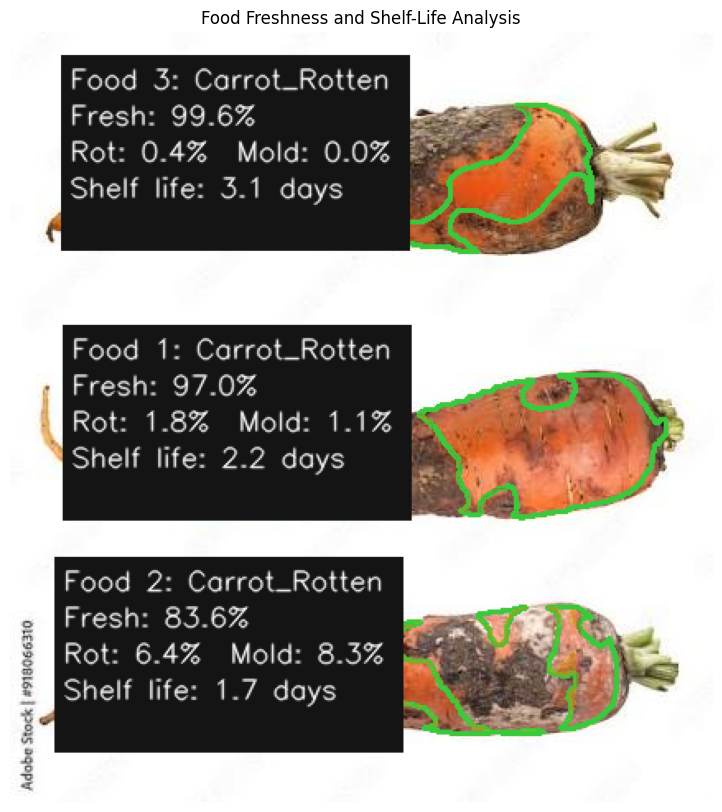

In [12]:
# ============================================================
# CELL 11 — FINAL VISUALIZATION
# ============================================================

# Make a copy of the original image
visualization = image.copy()

# ------------------------------------------------------------
# Draw each food object
# ------------------------------------------------------------

for food in food_objects:

    food_mask = food["mask"]

    # --------------------------------------------------------
    # Draw food outline
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        food_mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        visualization,
        contours,
        -1,
        (60, 200, 60),
        2
    )

    # --------------------------------------------------------
    # Draw rotten regions
    # --------------------------------------------------------

    rotten_mask = np.zeros(
        image.shape[:2],
        dtype=np.uint8
    )

    # Find rotten regions belonging to this food
    for j in range(len(segmentation_result.boxes)):

        class_id = int(
            segmentation_result.boxes.cls[j].item()
        )

        class_name = SEGMENTATION_CLASSES.get(
            class_id,
            segmentation_model.names.get(
                class_id,
                str(class_id)
            )
        )

        if class_name != "Rotten":
            continue

        mask = segmentation_result.masks.data[j].cpu().numpy()

        mask = cv2.resize(
            mask,
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        mask = mask > 0.5

        # Keep only rotten pixels inside this food
        overlap = food_mask & mask

        rotten_mask[overlap] = 255

    # Apply rotten overlay
    if rotten_mask.any():

        overlay = visualization.copy()

        overlay[rotten_mask > 0] = (30, 30, 220)

        visualization = cv2.addWeighted(
            visualization,
            0.70,
            overlay,
            0.30,
            0
        )

    # --------------------------------------------------------
    # Draw mold regions
    # --------------------------------------------------------

    mold_mask = np.zeros(
        image.shape[:2],
        dtype=np.uint8
    )

    for j in range(len(segmentation_result.boxes)):

        class_id = int(
            segmentation_result.boxes.cls[j].item()
        )

        class_name = SEGMENTATION_CLASSES.get(
            class_id,
            segmentation_model.names.get(
                class_id,
                str(class_id)
            )
        )

        if class_name != "Mold":
            continue

        mask = segmentation_result.masks.data[j].cpu().numpy()

        mask = cv2.resize(
            mask,
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        mask = mask > 0.5

        # Keep only mold pixels inside this food
        overlap = food_mask & mask

        mold_mask[overlap] = 255

    # Apply mold overlay
    if mold_mask.any():

        overlay = visualization.copy()

        overlay[mold_mask > 0] = (0, 200, 220)

        visualization = cv2.addWeighted(
            visualization,
            0.70,
            overlay,
            0.30,
            0
        )

    # --------------------------------------------------------
    # Get label position
    # --------------------------------------------------------

    ys, xs = np.where(food_mask)

    if len(xs) > 0 and len(ys) > 0:

        text_x = int(xs.min())
        text_y = max(25, int(ys.min()) - 10)

    else:

        text_x = 10
        text_y = 25

    # --------------------------------------------------------
    # Create label
    # --------------------------------------------------------

    label_1 = (
        f"Food {food['object_id']}: "
        f"{top1_class_name}"
    )

    label_2 = (
        f"Fresh: "
        f"{food['freshness_percentage']:.1f}%"
    )

    label_3 = (
        f"Rot: "
        f"{food['rotten_percentage']:.1f}%  "
        f"Mold: "
        f"{food['mold_percentage']:.1f}%"
    )

    label_4 = (
        f"Shelf life: "
        f"{food['predicted_shelf_life_days']:.1f} days"
    )

    # --------------------------------------------------------
    # Draw text background
    # --------------------------------------------------------

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.55
    thickness = 1

    labels = [
        label_1,
        label_2,
        label_3,
        label_4
    ]

    line_height = 22

    max_width = 0

    for label in labels:

        (text_width, _), _ = cv2.getTextSize(
            label,
            font,
            font_scale,
            thickness
        )

        max_width = max(
            max_width,
            text_width
        )

    box_height = line_height * len(labels) + 10

    cv2.rectangle(
        visualization,
        (
            text_x - 5,
            text_y - 20
        ),
        (
            text_x + max_width + 10,
            text_y + box_height
        ),
        (20, 20, 20),
        -1
    )

    # --------------------------------------------------------
    # Draw labels
    # --------------------------------------------------------

    for line_index, label in enumerate(labels):

        cv2.putText(
            visualization,
            label,
            (
                text_x,
                text_y + line_index * line_height
            ),
            font,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )


# ============================================================
# DISPLAY FINAL RESULT
# ============================================================

plt.figure(figsize=(14, 10))

plt.imshow(
    cv2.cvtColor(
        visualization,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Food Freshness and Shelf-Life Analysis"
)

plt.axis("off")
plt.show()

In [13]:
# ============================================================
# CELL 4 — CLASSIFY EACH INDIVIDUAL FOOD OBJECT
# ============================================================

# Classification settings
CLASSIFICATION_IMG_SIZE = 224

# ------------------------------------------------------------
# Make sure food_objects already exists from Cell 6
# ------------------------------------------------------------

if "food_objects" not in globals() or len(food_objects) == 0:
    raise RuntimeError(
        "food_objects is not available. "
        "Run Cells 5 and 6 first."
    )

# ------------------------------------------------------------
# Classify every individual segmented food object
# ------------------------------------------------------------

for food in food_objects:

    food_mask = food["mask"]

    # Find bounding box from the food mask
    ys, xs = np.where(food_mask)

    if len(xs) == 0 or len(ys) == 0:
        food["classification_name"] = "Unknown"
        food["classification_confidence"] = 0.0
        continue

    x1 = max(0, int(xs.min()))
    y1 = max(0, int(ys.min()))
    x2 = min(image.shape[1], int(xs.max()) + 1)
    y2 = min(image.shape[0], int(ys.max()) + 1)

    # Crop individual food
    food_crop = image[y1:y2, x1:x2].copy()

    if food_crop.size == 0:
        food["classification_name"] = "Unknown"
        food["classification_confidence"] = 0.0
        continue

    # Run classification on this individual food crop
    results = classification_model.predict(
        source=food_crop,
        imgsz=CLASSIFICATION_IMG_SIZE,
        verbose=False
    )

    result = results[0]

    class_id = int(result.probs.top1)
    confidence = float(result.probs.top1conf)

    class_name = classification_model.names[class_id]

    # Store classification result inside this food object
    food["classification_class_id"] = class_id
    food["classification_name"] = class_name
    food["classification_confidence"] = confidence
    food["crop"] = food_crop
    food["bbox"] = [x1, y1, x2, y2]


# ============================================================
# DISPLAY INDIVIDUAL CLASSIFICATION RESULTS
# ============================================================

print("\nIndividual Food Classification")
print("==============================")

for food in food_objects:

    print(
        f"Food Object {food['object_id']}: "
        f"{food['classification_name']} | "
        f"Confidence: "
        f"{food['classification_confidence']:.2%}"
    )


Individual Food Classification
Food Object 1: Carrot_Rotten | Confidence: 100.00%
Food Object 2: Carrot_Rotten | Confidence: 91.27%
Food Object 3: Carrot_Rotten | Confidence: 99.85%


In [14]:
# ============================================================
# CELL 5 — TEST INDIVIDUAL FOOD CLASSIFICATION + SEGMENTATION
# ============================================================

print("Individual food classification and segmentation results")
print("=" * 60)

for food in food_objects:

    print(
        f"\nFood Object {food['object_id']}"
    )

    print(
        "Classification :",
        food["classification_name"]
    )

    print(
        "Confidence     :",
        f"{food['classification_confidence']:.2%}"
    )

    print(
        "Segmentation   :",
        food["class_name"]
    )

print("\nCell 5 completed successfully.")

Individual food classification and segmentation results

Food Object 1
Classification : Carrot_Rotten
Confidence     : 100.00%
Segmentation   : Vegetable

Food Object 2
Classification : Carrot_Rotten
Confidence     : 91.27%
Segmentation   : Vegetable

Food Object 3
Classification : Carrot_Rotten
Confidence     : 99.85%
Segmentation   : Vegetable

Cell 5 completed successfully.


In [15]:
# ============================================================
# CELL 6 — CALCULATE PER-FOOD SPOILAGE AREAS
# ============================================================

SPOILAGE_CLASSES = {"Rotten", "Mold"}

boxes = segmentation_result.boxes
masks = segmentation_result.masks

if boxes is None or len(boxes) == 0:
    raise RuntimeError("No segmentation objects were detected.")

if masks is None:
    raise RuntimeError("Segmentation masks are not available.")

if "food_objects" not in globals() or len(food_objects) == 0:
    raise RuntimeError("No food objects are available.")


# ------------------------------------------------------------
# Process each food object
# ------------------------------------------------------------

for food in food_objects:

    food_mask = food["mask"]

    food_rotten_area = 0
    food_mold_area = 0

    # --------------------------------------------------------
    # Compare this food mask with every spoilage mask
    # --------------------------------------------------------

    for j in range(len(boxes)):

        class_id = int(
            boxes.cls[j].item()
        )

        class_name = SEGMENTATION_CLASSES.get(
            class_id,
            segmentation_model.names.get(
                class_id,
                str(class_id)
            )
        )

        if class_name not in SPOILAGE_CLASSES:
            continue

        # Get spoilage mask
        spoilage_mask = masks.data[j].cpu().numpy()

        spoilage_mask = cv2.resize(
            spoilage_mask,
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        spoilage_mask = spoilage_mask > 0.5

        # ----------------------------------------------------
        # Only count spoilage INSIDE this food object
        # ----------------------------------------------------

        overlap = food_mask & spoilage_mask

        overlap_area = int(overlap.sum())

        if class_name == "Rotten":
            food_rotten_area += overlap_area

        elif class_name == "Mold":
            food_mold_area += overlap_area


    # --------------------------------------------------------
    # Store areas
    # --------------------------------------------------------

    food["rotten_area_pixels"] = food_rotten_area
    food["mold_area_pixels"] = food_mold_area

    food_area = food["food_area_pixels"]

    # --------------------------------------------------------
    # Calculate percentages
    # --------------------------------------------------------

    if food_area > 0:

        food["rotten_percentage"] = min(
            100.0,
            (food_rotten_area / food_area) * 100
        )

        food["mold_percentage"] = min(
            100.0,
            (food_mold_area / food_area) * 100
        )

    else:

        food["rotten_percentage"] = 0.0
        food["mold_percentage"] = 0.0


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\nPer-Food Segmentation Analysis")
print("================================")

for food in food_objects:

    print(
        f"\nFood Object {food['object_id']}"
    )

    print(
        "Classification      :",
        food["classification_name"]
    )

    print(
        "Classification conf.:",
        f"{food['classification_confidence']:.2%}"
    )

    print(
        "Food area           :",
        food["food_area_pixels"],
        "pixels"
    )

    print(
        "Rotten area         :",
        food["rotten_area_pixels"],
        "pixels"
    )

    print(
        "Mold area           :",
        food["mold_area_pixels"],
        "pixels"
    )

    print(
        "Rotten percentage   :",
        f"{food['rotten_percentage']:.2f}%"
    )

    print(
        "Mold percentage     :",
        f"{food['mold_percentage']:.2f}%"
    )


Per-Food Segmentation Analysis

Food Object 1
Classification      : Carrot_Rotten
Classification conf.: 100.00%
Food area           : 12326 pixels
Rotten area         : 218 pixels
Mold area           : 131 pixels
Rotten percentage   : 1.77%
Mold percentage     : 1.06%

Food Object 2
Classification      : Carrot_Rotten
Classification conf.: 91.27%
Food area           : 9645 pixels
Rotten area         : 622 pixels
Mold area           : 799 pixels
Rotten percentage   : 6.45%
Mold percentage     : 8.28%

Food Object 3
Classification      : Carrot_Rotten
Classification conf.: 99.85%
Food area           : 9842 pixels
Rotten area         : 43 pixels
Mold area           : 0 pixels
Rotten percentage   : 0.44%
Mold percentage     : 0.00%


In [16]:
# ============================================================
# CELL 7 — CALCULATE FRESHNESS FOR EACH FOOD OBJECT
# ============================================================

ROTTEN_WEIGHT = 1.0
MOLD_WEIGHT = 1.2

for food in food_objects:

    rotten_percentage = food["rotten_percentage"]
    mold_percentage = food["mold_percentage"]

    # Calculate spoilage penalty
    spoilage_score = (
        rotten_percentage * ROTTEN_WEIGHT
        + mold_percentage * MOLD_WEIGHT
    )

    # Calculate freshness
    freshness_percentage = 100.0 - spoilage_score

    # Keep freshness between 0 and 100
    freshness_percentage = max(
        0.0,
        min(100.0, freshness_percentage)
    )

    # Store result
    food["freshness_percentage"] = freshness_percentage


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\nPer-Food Freshness Analysis")
print("============================")

for food in food_objects:

    print(
        f"\nFood Object {food['object_id']}"
    )

    print(
        "Food                :",
        food["classification_name"]
    )

    print(
        "Rotten percentage   :",
        f"{food['rotten_percentage']:.2f}%"
    )

    print(
        "Mold percentage     :",
        f"{food['mold_percentage']:.2f}%"
    )

    print(
        "Freshness           :",
        f"{food['freshness_percentage']:.2f}%"
    )


Per-Food Freshness Analysis

Food Object 1
Food                : Carrot_Rotten
Rotten percentage   : 1.77%
Mold percentage     : 1.06%
Freshness           : 96.96%

Food Object 2
Food                : Carrot_Rotten
Rotten percentage   : 6.45%
Mold percentage     : 8.28%
Freshness           : 83.61%

Food Object 3
Food                : Carrot_Rotten
Rotten percentage   : 0.44%
Mold percentage     : 0.00%
Freshness           : 99.56%


In [17]:
# ============================================================
# CELL 8 — BUILD XGBOOST FEATURES
# ============================================================

# Default storage conditions
temperature_c = 25.0
humidity_percent = 60.0
storage_duration_days = 0.0

storage_area = "Room Temperature"
packaging_material = "Loose"


# ------------------------------------------------------------
# Function to create features for one food object
# ------------------------------------------------------------

def create_shelf_life_features(food):

    # Start with all training columns as 0
    features = {
        column: 0
        for column in shelf_life_feature_columns
    }

    # --------------------------------------------------------
    # Numerical features
    # --------------------------------------------------------

    if "temperature_c" in features:
        features["temperature_c"] = temperature_c

    if "humidity_percent" in features:
        features["humidity_percent"] = humidity_percent

    if "freshness_percentage" in features:
        features["freshness_percentage"] = (
            food["freshness_percentage"]
        )

    if "storage_duration_days" in features:
        features["storage_duration_days"] = (
            storage_duration_days
        )

    # --------------------------------------------------------
    # Food category
    # --------------------------------------------------------

    food_name = food["classification_name"]

    food_category_column = (
        f"food_category_{food_name}"
    )

    if food_category_column in features:
        features[food_category_column] = 1

    # --------------------------------------------------------
    # Food type
    # --------------------------------------------------------

    if "food_type_Vegetable" in features:

        if food["class_name"] == "Vegetable":
            features["food_type_Vegetable"] = 1

    # --------------------------------------------------------
    # Storage area
    # --------------------------------------------------------

    storage_area_column = (
        f"storage_area_{storage_area}"
    )

    if storage_area_column in features:
        features[storage_area_column] = 1

    # --------------------------------------------------------
    # Packaging material
    # --------------------------------------------------------

    packaging_column = (
        f"packaging_material_{packaging_material}"
    )

    if packaging_column in features:
        features[packaging_column] = 1

    # --------------------------------------------------------
    # Create DataFrame using EXACT training column order
    # --------------------------------------------------------

    feature_df = pd.DataFrame(
        [[features[column] for column in shelf_life_feature_columns]],
        columns=shelf_life_feature_columns
    )

    return feature_df


# ============================================================
# CREATE FEATURES FOR EACH FOOD OBJECT
# ============================================================

for food in food_objects:

    food["shelf_life_features"] = (
        create_shelf_life_features(food)
    )


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("XGBoost feature creation completed.")
print()

for food in food_objects:

    print(
        f"Food Object {food['object_id']} "
        f"({food['classification_name']})"
    )

    print(
        food["shelf_life_features"].to_string(
            index=False
        )
    )

    print("-" * 70)

XGBoost feature creation completed.

Food Object 1 (Carrot_Rotten)
 temperature_c  humidity_percent  freshness_percentage  storage_duration_days  food_category_Banana  food_category_Beetroot  food_category_Bell Pepper  food_category_Cabbage  food_category_Carrot  food_category_Cauliflower  food_category_Chilli Pepper  food_category_Corn  food_category_Cucumber  food_category_Eggplant  food_category_Ginger  food_category_Grapes  food_category_Guava  food_category_Kiwi  food_category_Lemon  food_category_Mango  food_category_Onion  food_category_Orange  food_category_Papaya  food_category_Potato  food_category_Tomato  food_type_Vegetable  storage_area_Dark Dry Storage  storage_area_Pantry  storage_area_Refrigerator  storage_area_Room Temperature  packaging_material_Loose  packaging_material_Mesh/Net Bag  packaging_material_Paper Bag  packaging_material_Perforated Plastic Bag  packaging_material_Plastic Bag  packaging_material_Plastic Container  packaging_material_Plastic Wrap  packaging_

In [18]:
# ============================================================
# CELL 9 — XGBOOST SHELF-LIFE PREDICTION
# ============================================================

print("Testing XGBoost shelf-life model...")
print()

for food in food_objects:

    # Features created for this individual food
    features = food["shelf_life_features"]

    # Predict shelf life
    prediction = shelf_life_model.predict(features)

    # Convert prediction to a single number
    predicted_shelf_life = float(prediction[0])

    # Prevent negative shelf-life values
    predicted_shelf_life = max(
        0.0,
        predicted_shelf_life
    )

    # Store prediction
    food["predicted_shelf_life_days"] = (
        predicted_shelf_life
    )

    # Display result
    print(
        f"Food Object {food['object_id']}"
    )

    print(
        "Food type            :",
        food["classification_name"]
    )

    print(
        "Freshness            :",
        f"{food['freshness_percentage']:.2f}%"
    )

    print(
        "Rotten percentage    :",
        f"{food['rotten_percentage']:.2f}%"
    )

    print(
        "Mold percentage      :",
        f"{food['mold_percentage']:.2f}%"
    )

    print(
        "Predicted shelf life :",
        f"{predicted_shelf_life:.2f} days"
    )

    print("-" * 60)

Testing XGBoost shelf-life model...

Food Object 1
Food type            : Carrot_Rotten
Freshness            : 96.96%
Rotten percentage    : 1.77%
Mold percentage      : 1.06%
Predicted shelf life : 2.25 days
------------------------------------------------------------
Food Object 2
Food type            : Carrot_Rotten
Freshness            : 83.61%
Rotten percentage    : 6.45%
Mold percentage      : 8.28%
Predicted shelf life : 1.73 days
------------------------------------------------------------
Food Object 3
Food type            : Carrot_Rotten
Freshness            : 99.56%
Rotten percentage    : 0.44%
Mold percentage      : 0.00%
Predicted shelf life : 3.12 days
------------------------------------------------------------


In [19]:
# ============================================================
# CELL 10 — FINAL RESULTS TABLE
# ============================================================

summary_rows = []

for food in food_objects:

    summary_rows.append({
        "Food Object":
            food["object_id"],

        "Food Type":
            food["classification_name"],

        "Classification Confidence (%)":
            round(
                food["classification_confidence"] * 100,
                2
            ),

        "Freshness (%)":
            round(
                food["freshness_percentage"],
                2
            ),

        "Rotten (%)":
            round(
                food["rotten_percentage"],
                2
            ),

        "Mold (%)":
            round(
                food["mold_percentage"],
                2
            ),

        "Shelf Life (days)":
            round(
                food["predicted_shelf_life_days"],
                2
            )
    })


# Create final DataFrame
final_results_df = pd.DataFrame(summary_rows)


# ============================================================
# DISPLAY FINAL RESULTS
# ============================================================

print("=" * 80)
print("FINAL FOOD FRESHNESS AND SHELF-LIFE RESULTS")
print("=" * 80)

display(final_results_df)

FINAL FOOD FRESHNESS AND SHELF-LIFE RESULTS


,Food Object,Food Type,Classification Confidence (%),Freshness (%),Rotten (%),Mold (%),Shelf Life (days)
0,1,Carrot_Rotten,100.00,96.96,1.77,1.06,2.25
1,2,Carrot_Rotten,91.27,83.61,6.45,8.28,1.73
2,3,Carrot_Rotten,99.85,99.56,0.44,0.00,3.12


FINAL WEIGHTED FRESHNESS SCORE

Food Object 1
Food Type               : Carrot_Rotten
Visual Condition (40%)  : 96.96
Storage Conditions (25%): 100.00
Shelf-Life (20%)        : 32.09
Product Age (15%)       : 100.00
FINAL FRESHNESS SCORE   : 85.20/100

Food Object 2
Food Type               : Carrot_Rotten
Visual Condition (40%)  : 83.61
Storage Conditions (25%): 100.00
Shelf-Life (20%)        : 24.77
Product Age (15%)       : 100.00
FINAL FRESHNESS SCORE   : 78.40/100

Food Object 3
Food Type               : Carrot_Rotten
Visual Condition (40%)  : 99.56
Storage Conditions (25%): 100.00
Shelf-Life (20%)        : 44.61
Product Age (15%)       : 100.00
FINAL FRESHNESS SCORE   : 88.75/100


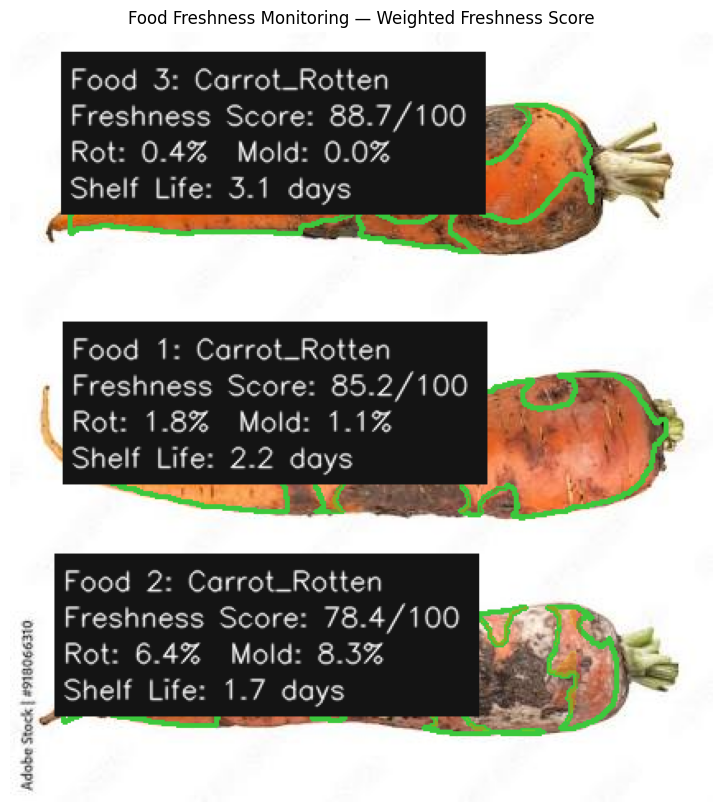

In [20]:
# ============================================================
# CELL 11 — FINAL WEIGHTED FRESHNESS SCORE + VISUALIZATION
# ============================================================

visualization = image.copy()

# ============================================================
# WEIGHTS FROM PROJECT DOCUMENT
# ============================================================

VISUAL_WEIGHT = 0.40
STORAGE_WEIGHT = 0.25
SHELF_LIFE_WEIGHT = 0.20
AGE_WEIGHT = 0.15


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def calculate_storage_score(temperature, humidity):
    """
    Convert storage conditions into a 0-100 score.

    Reference condition:
        Temperature = 25 C
        Humidity    = 60 %

    The score decreases as conditions move away
    from these reference values.
    """

    temperature_penalty = abs(temperature - 25.0) * 2.0
    humidity_penalty = abs(humidity - 60.0) * 0.5

    score = 100.0 - (
        temperature_penalty +
        humidity_penalty
    )

    return max(0.0, min(100.0, score))


def calculate_shelf_life_score(shelf_life_days):
    """
    Convert predicted remaining shelf life into a 0-100 score.

    7 days or more = 100
    0 days = 0
    """

    score = (
        shelf_life_days / 7.0
    ) * 100.0

    return max(0.0, min(100.0, score))


def calculate_product_age_score(storage_days):
    """
    Convert storage duration into a 0-100 product-age score.

    0 days = 100
    7 days or more = 0
    """

    score = 100.0 - (
        (storage_days / 7.0) * 100.0
    )

    return max(0.0, min(100.0, score))


# ============================================================
# CALCULATE FINAL SCORE FOR EACH FOOD
# ============================================================

for food in food_objects:

    # --------------------------------------------------------
    # 1. VISUAL CONDITION SCORE
    # --------------------------------------------------------
    #
    # Cell 7 already calculated freshness_percentage
    # from rotten + mold segmentation.
    #
    visual_condition_score = (
        food["freshness_percentage"]
    )

    # --------------------------------------------------------
    # 2. STORAGE CONDITION SCORE
    # --------------------------------------------------------

    storage_condition_score = calculate_storage_score(
        temperature_c,
        humidity_percent
    )

    # --------------------------------------------------------
    # 3. SHELF-LIFE SCORE
    # --------------------------------------------------------

    shelf_life_score = calculate_shelf_life_score(
        food["predicted_shelf_life_days"]
    )

    # --------------------------------------------------------
    # 4. PRODUCT AGE SCORE
    # --------------------------------------------------------

    product_age_score = calculate_product_age_score(
        storage_duration_days
    )

    # --------------------------------------------------------
    # 5. FINAL WEIGHTED FRESHNESS SCORE
    # --------------------------------------------------------

    final_freshness_score = (
        visual_condition_score * VISUAL_WEIGHT
        +
        storage_condition_score * STORAGE_WEIGHT
        +
        shelf_life_score * SHELF_LIFE_WEIGHT
        +
        product_age_score * AGE_WEIGHT
    )

    final_freshness_score = max(
        0.0,
        min(100.0, final_freshness_score)
    )

    # Store all component scores
    food["visual_condition_score"] = (
        visual_condition_score
    )

    food["storage_condition_score"] = (
        storage_condition_score
    )

    food["shelf_life_score"] = (
        shelf_life_score
    )

    food["product_age_score"] = (
        product_age_score
    )

    food["final_freshness_score"] = (
        final_freshness_score
    )


# ============================================================
# PRINT FINAL WEIGHTED SCORES
# ============================================================

print("=" * 80)
print("FINAL WEIGHTED FRESHNESS SCORE")
print("=" * 80)

for food in food_objects:

    print(
        f"\nFood Object {food['object_id']}"
    )

    print(
        "Food Type               :",
        food["classification_name"]
    )

    print(
        "Visual Condition (40%)  :",
        f"{food['visual_condition_score']:.2f}"
    )

    print(
        "Storage Conditions (25%):",
        f"{food['storage_condition_score']:.2f}"
    )

    print(
        "Shelf-Life (20%)        :",
        f"{food['shelf_life_score']:.2f}"
    )

    print(
        "Product Age (15%)       :",
        f"{food['product_age_score']:.2f}"
    )

    print(
        "FINAL FRESHNESS SCORE   :",
        f"{food['final_freshness_score']:.2f}/100"
    )


# ============================================================
# VISUALIZATION
# ============================================================

for food in food_objects:

    food_mask = food["mask"]

    # --------------------------------------------------------
    # Food outline
    # --------------------------------------------------------

    contours, _ = cv2.findContours(
        food_mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        visualization,
        contours,
        -1,
        (60, 200, 60),
        2
    )

    # --------------------------------------------------------
    # Rotten and mold masks
    # --------------------------------------------------------

    rotten_mask = np.zeros(
        image.shape[:2],
        dtype=np.uint8
    )

    mold_mask = np.zeros(
        image.shape[:2],
        dtype=np.uint8
    )

    for j in range(len(segmentation_result.boxes)):

        class_id = int(
            segmentation_result.boxes.cls[j].item()
        )

        class_name = SEGMENTATION_CLASSES.get(
            class_id,
            segmentation_model.names.get(
                class_id,
                str(class_id)
            )
        )

        if class_name not in {"Rotten", "Mold"}:
            continue

        spoilage_mask = (
            segmentation_result
            .masks
            .data[j]
            .cpu()
            .numpy()
        )

        spoilage_mask = cv2.resize(
            spoilage_mask,
            (image.shape[1], image.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

        spoilage_mask = spoilage_mask > 0.5

        overlap = food_mask & spoilage_mask

        if class_name == "Rotten":
            rotten_mask[overlap] = 255

        elif class_name == "Mold":
            mold_mask[overlap] = 255

    # --------------------------------------------------------
    # Rotten overlay
    # --------------------------------------------------------

    if rotten_mask.any():

        overlay = visualization.copy()

        overlay[rotten_mask > 0] = (30, 30, 220)

        visualization = cv2.addWeighted(
            visualization,
            0.70,
            overlay,
            0.30,
            0
        )

    # --------------------------------------------------------
    # Mold overlay
    # --------------------------------------------------------

    if mold_mask.any():

        overlay = visualization.copy()

        overlay[mold_mask > 0] = (0, 200, 220)

        visualization = cv2.addWeighted(
            visualization,
            0.70,
            overlay,
            0.30,
            0
        )

    # --------------------------------------------------------
    # Label position
    # --------------------------------------------------------

    ys, xs = np.where(food_mask)

    if len(xs) > 0 and len(ys) > 0:

        text_x = int(xs.min())
        text_y = max(
            30,
            int(ys.min()) - 10
        )

    else:

        text_x = 10
        text_y = 30

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    labels = [
        f"Food {food['object_id']}: {food['classification_name']}",
        f"Freshness Score: {food['final_freshness_score']:.1f}/100",
        f"Rot: {food['rotten_percentage']:.1f}%  Mold: {food['mold_percentage']:.1f}%",
        f"Shelf Life: {food['predicted_shelf_life_days']:.1f} days"
    ]

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.55
    thickness = 1
    line_height = 22

    max_width = 0

    for label in labels:

        (text_width, _), _ = cv2.getTextSize(
            label,
            font,
            font_scale,
            thickness
        )

        max_width = max(
            max_width,
            text_width
        )

    box_height = (
        line_height * len(labels) + 10
    )

    box_x1 = max(
        0,
        text_x - 5
    )

    box_y1 = max(
        0,
        text_y - 22
    )

    box_x2 = min(
        visualization.shape[1],
        box_x1 + max_width + 15
    )

    box_y2 = min(
        visualization.shape[0],
        box_y1 + box_height
    )

    # --------------------------------------------------------
    # Text background
    # --------------------------------------------------------

    cv2.rectangle(
        visualization,
        (box_x1, box_y1),
        (box_x2, box_y2),
        (20, 20, 20),
        -1
    )

    # --------------------------------------------------------
    # Draw labels
    # --------------------------------------------------------

    for line_index, label in enumerate(labels):

        cv2.putText(
            visualization,
            label,
            (
                text_x,
                text_y + line_index * line_height
            ),
            font,
            font_scale,
            (255, 255, 255),
            thickness,
            cv2.LINE_AA
        )


# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(14, 10))

plt.imshow(
    cv2.cvtColor(
        visualization,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Food Freshness Monitoring — Weighted Freshness Score"
)

plt.axis("off")
plt.show()